## Exploratory Data Analysis (EDA)

Before conducting hypothesis testing, exploratory data analysis was performed to understand the structure of the dataset, examine variable distributions, detect possible outliers, and identify patterns related to experience level, salary, demand, and education requirements.

In [2]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


df2 = pd.read_csv("ai_jobs_market_cleaned.csv")

print("Dataset loaded successfully!")
print("Shape:", df2.shape)

df2.head()

Dataset loaded successfully!
Shape: (1500, 16)


,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,industry,required_skills,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,is_llm_role,entry_vs_senior,salary_midpoint_check
0,AI Engineering,Senior,7,Master,239000.0,155000,290000,Finance,APIs|Planning Systems|Python|Cloud|SQL|Leadership,13.1,96,16.9,6.8,1,Senior,222500.0
1,AI Engineering,Senior,2,Bachelor,166000.0,90000,200000,Finance,Python|Documentation|LLM APIs|Prompt Design|NL...,5.4,82,11.6,6.2,1,Senior,145000.0
2,AI Engineering,Senior,4,Associate,360000.0,160000,300000,Finance,Vector DBs|Python|Prompt Engineering|Fine-tuni...,9.1,98,42.7,7.7,1,Senior,230000.0
3,Data Engineering,Senior,3,Bachelor,161000.0,130000,220000,Technology,Feature Stores|Spark|ETL|Airflow|dbt|SQL|Pytho...,12.0,88,6.7,9.5,0,Senior,175000.0
4,Product,Lead,5,Bootcamp/Self-taught,283000.0,140000,260000,Automotive,Data Analysis|Stakeholder Mgmt|Agile|Cloud|Pro...,9.4,85,17.3,8.9,0,Other,200000.0


The cleaned dataset is loaded and verified. This ensures that all variables are ready for exploratory analysis.

### 1. Dataset Overview

The first step is to examine the size of the dataset, column names, data types, and summary statistics. This helps verify that the cleaning process worked correctly and gives a general understanding of the variables.

In [3]:
print("Shape of dataset:", df2.shape)
print("\nColumn names:")
print(df2.columns.tolist())

print("\nData types:")
print(df2.dtypes)

print("\nSummary statistics:")
print(df2.describe(include="all"))

Shape of dataset: (1500, 16)

Column names:
['job_category', 'experience_level', 'years_of_experience', 'education_required', 'annual_salary_usd', 'salary_min_usd', 'salary_max_usd', 'industry', 'required_skills', 'ai_salary_premium_pct', 'demand_score', 'demand_growth_yoy_pct', 'benefits_score_10', 'is_llm_role', 'entry_vs_senior', 'salary_midpoint_check']

Data types:
job_category              object
experience_level          object
years_of_experience        int64
education_required        object
annual_salary_usd        float64
salary_min_usd             int64
salary_max_usd             int64
industry                  object
required_skills           object
ai_salary_premium_pct    float64
demand_score               int64
demand_growth_yoy_pct    float64
benefits_score_10        float64
is_llm_role                int64
entry_vs_senior           object
salary_midpoint_check    float64
dtype: object

Summary statistics:
          job_category experience_level  years_of_experience  \


This step provides a general overview of the dataset, including the number of observations, variable types, and summary statistics for numerical variables. It helps ensure that the data is correctly formatted and ready for analysis.

### 2. Distribution of Experience Levels

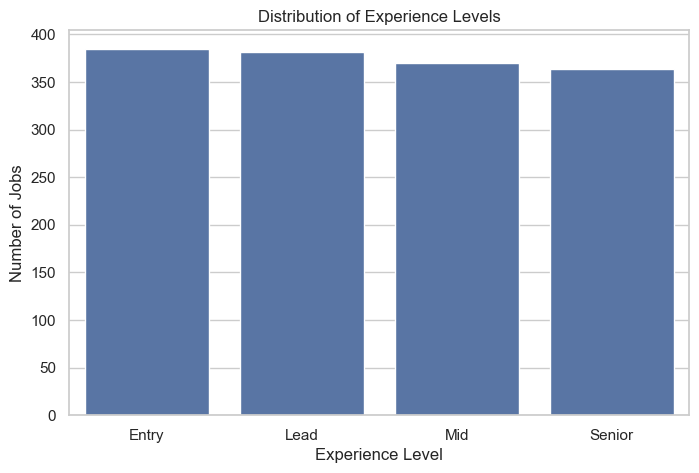

In [4]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df2,
    x="experience_level",
    order=df2["experience_level"].value_counts().index
)

plt.title("Distribution of Experience Levels")
plt.xlabel("Experience Level")
plt.ylabel("Number of Jobs")

plt.show()

This plot shows how job listings are distributed across experience levels. It is important to verify that there is sufficient data in each category before conducting statistical tests.

### 3. Salary Analysis

#### 3.1 Salary Distribution

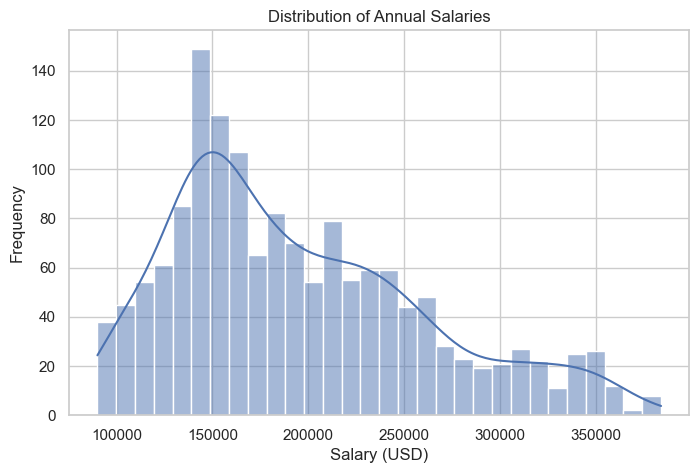

In [5]:
plt.figure(figsize=(8, 5))

sns.histplot(df2["annual_salary_usd"], bins=30, kde=True)

plt.title("Distribution of Annual Salaries")
plt.xlabel("Salary (USD)")
plt.ylabel("Frequency")

plt.show()

The salary distribution helps identify skewness and potential outliers. This is important because highly skewed data may affect statistical tests.

#### 3.2 Salary by Experience Level

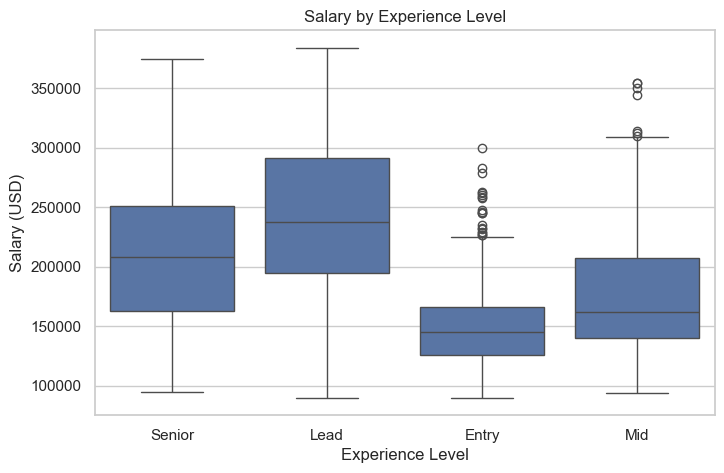

In [6]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df2,
    x="experience_level",
    y="annual_salary_usd"
)

plt.title("Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Salary (USD)")

plt.show()

This visualization compares salary distributions across experience levels. It provides an initial indication of whether salary increases with experience, which is central to the second hypothesis.

## 4. AI Salary Premium Analysis

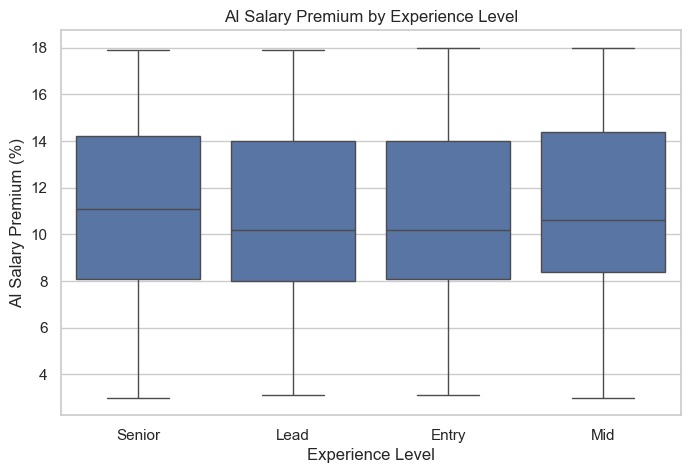

In [7]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df2,
    x="experience_level",
    y="ai_salary_premium_pct"
)

plt.title("AI Salary Premium by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("AI Salary Premium (%)")

plt.show()

This plot shows how AI-related salary premiums vary across experience levels. It helps assess whether senior roles benefit more from AI-related jobs.

## 5. Demand Score Analysis

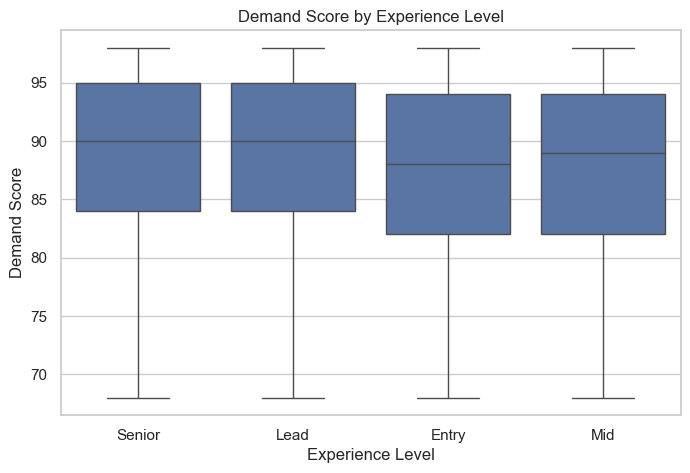

In [9]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df2,
    x="experience_level",
    y="demand_score"
)

plt.title("Demand Score by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Demand Score")

plt.show()

This visualization explores whether demand for jobs differs across experience levels. It directly supports the first hypothesis regarding entry-level accessibility.

## 6. Education Requirement Analysis

In [10]:
edu_table = pd.crosstab(df2["experience_level"], df2["education_required"])
print(edu_table)

education_required  Associate  Bachelor  Bootcamp/Self-taught  Master  PhD
experience_level                                                          
Entry                      82        83                    73      68   79
Lead                       65        75                    85      88   68
Mid                        65        80                    64      90   71
Senior                     84        73                    75      70   62


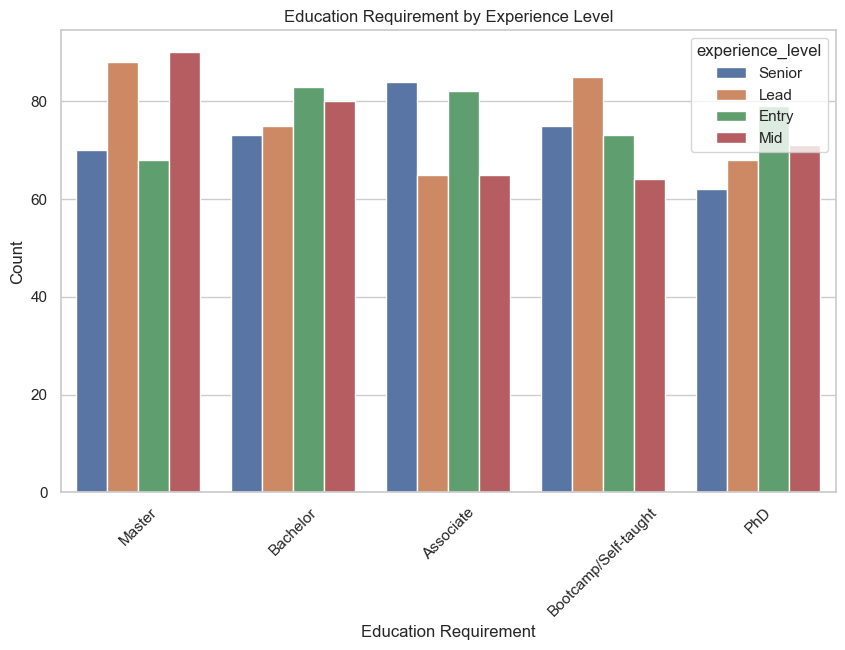

In [11]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df2,
    x="education_required",
    hue="experience_level"
)

plt.title("Education Requirement by Experience Level")
plt.xlabel("Education Requirement")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.show()

This analysis examines how education requirements vary across experience levels. It is important for evaluating whether entry-level jobs still require formal degrees.

## 7. Correlation Analysis

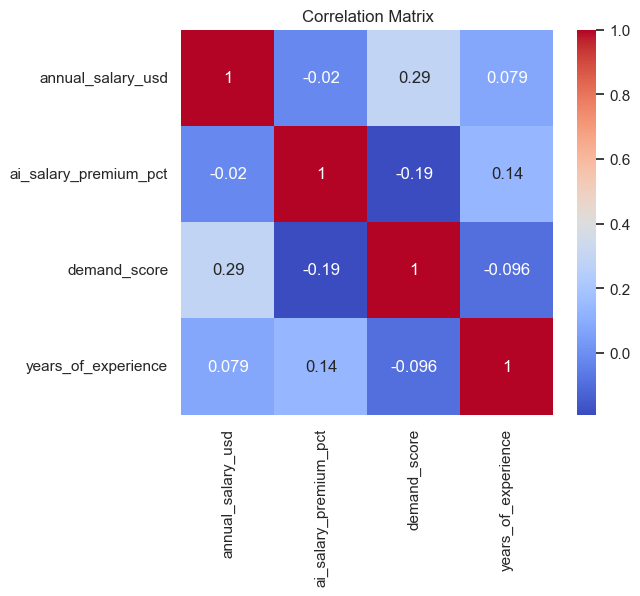

In [12]:
plt.figure(figsize=(6, 5))

corr = df2[[
    "annual_salary_usd",
    "ai_salary_premium_pct",
    "demand_score",
    "years_of_experience"
]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

The correlation matrix shows relationships between key numerical variables. It helps identify whether variables such as experience, salary, and demand are positively or negatively related.